In [ ]:
##Different Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR  
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer, RobustScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from functionsFolder.config import text_data, biometric_data, adv_to_del, team_to_del, id, useless, index, to_keep
from functionsFolder.preProcessingAuto import preprocess_working_df
from functionsFolder.modelAutomation import get_features_and_target, clean_features, evaluate_models, prepare_features

# Custom MAPE function (since sklearn does not have it directly)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

##Different Paths
HOME = r"C:\Users\Utilisateur\Desktop\Master ULB\Mémoire"
W_DB = r"\Database\Working db"
STACK = r"\Thesis - Code\database\Database Updates\Database stack"

In [5]:
base_df = pd.read_excel(HOME + STACK + r"\looping_df_1744186780.4209929.xlsx")
RECOVERY_OPP = HOME + W_DB + r"\Features\Team data\4-4-2025_team.xlsx"

In [10]:
#add the mean of every position in the advance part and scouting evaluation part
base_df[to_keep['adv']] = base_df[to_keep['adv']].fillna(base_df.groupby('Pos_x_features')[to_keep['adv']].transform('median'))
base_df[to_keep['scouting_reports']] = base_df[to_keep['scouting_reports']].fillna(base_df.groupby('Pos_x_features')[to_keep['scouting_reports']].transform('median'))
processed_df = preprocess_working_df(base_df, recovery_file=RECOVERY_OPP)

2025-04-25 16:46:50,292 - INFO - Starting full preprocessing pipeline...
2025-04-25 16:46:50,296 - INFO - Creating dummy variables...
2025-04-25 16:46:50,321 - INFO - After dummy variable creation: shape = (958, 364)
2025-04-25 16:46:50,323 - INFO - Categorizing and one-hot encoding categorical features...
2025-04-25 16:46:50,384 - INFO - After categorization and one-hot encoding: shape = (958, 379)
2025-04-25 16:46:50,384 - INFO - Processing unstructured text data...
2025-04-25 16:46:54,788 - INFO - After TF-IDF vectorization: shape = (958, 100)
2025-04-25 16:46:54,794 - INFO - After after TF-IDF merge: shape = (958, 479)
2025-04-25 16:46:54,795 - INFO - Imputing opponent columns based on team data...
2025-04-25 16:46:56,318 - INFO - After imputation using team data: shape = (958, 479)
2025-04-25 16:46:56,318 - INFO - Imputing opponent columns using recovery data...
2025-04-25 16:47:01,899 - INFO - After imputation using recovery data: shape = (958, 479)
2025-04-25 16:47:01,899 - INFO

In [11]:
#Get a copy of the dataset
working_df = processed_df.copy()
# Get initial features and targets
raw_features, target = get_features_and_target(working_df) #Get the features and target columns' name in separate lists


# Step 2: Prepare feature list (optionally re-adding 'adv' and 'scouting_reports')
include_subsets = ['per_40', 'team', 'opp', 'adv', 'scouting_reports']
features, included_types = prepare_features( #prepare the features' space
    base_features=raw_features,
    df=working_df,
    useless_list=useless, #list of features that we do not use 
    feature_dict=to_keep, #dictionnary of the features that we keep 
    include_keys=include_subsets #the keys to the dictionnary above
)

In [12]:
#Change the height from feet to inches 
working_df['Height_features'] = working_df['Height_features'].apply(
    lambda x: int(x.split('-')[0]) * 12 + int(x.split('-')[1])
)

In [111]:
filtered_list = [element for element in features if 'text' not in element]

In [ ]:
working_df = processed_df.copy()
# Get initial features and targets
raw_features, target = get_features_and_target(working_df) #Get the features and target columns' name in separate lists


# Step 2: Prepare feature list (optionally re-adding 'adv' and 'scouting_reports')
include_subsets = ['per_40', 'team', 'opp', 'adv']
features, included_types = prepare_features( #prepare the features' space
    base_features=raw_features,
    df=working_df,
    useless_list=useless, #list of features that we do not use 
    feature_dict=to_keep, #dictionnary of the features that we keep 
    include_keys=include_subsets #the keys to the dictionnary above
)
# Define the set of models to test
models_dict = {
    "XGBoost": XGBRegressor(random_state=42),
    "SVR": SVR(kernel='rbf', C=1.0, epsilon=0.1)
}

# Define scalers to try
scalers_dict = {
    "StandardScaler": StandardScaler(),
}
test_size = [0.1, 0.15, 0.2]

dic_metr = ['WS', 'WS/48']

# Evaluate models
results = evaluate_models(df=working_df,
                          features=features,
                          metric=dic_metr[1],
                          season_range=range(1, 4),
                          index_col='Player_features',
                          drop_cols=['Height_features'],  # if you want to drop specific features
                          test_sizes=test_size,
                          models_dict=models_dict, 
                          scalers_dict=scalers_dict,
                          feature_types=include_subsets
                          )

# Show the aggregated results
print("\nSummary of evaluations:")
results.sort_values(ascending=False, by='R2')

In [142]:
test = ['per_40_PTS_features', 'per_40_AST_features', 'per_40_TRB_features', 'advanced_WS_features', 'Height_features', 'advanced_BPM_features']

In [143]:
# 1. Generate Synthetic Data (Replace with your dataset)
X = working_df[test]
y = working_df['WS/48-1_target']

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Standardize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Apply PCA (Retain 95% variance)
pca = PCA(n_components=0.9)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print(f"Reduced features after PCA: {X_train_pca.shape[1]}")


Reduced features after PCA: 4


In [127]:
# 5. Define 3-Fold CV
cv = KFold(n_splits=3, shuffle=True, random_state=42)

In [144]:
# 6. Hyperparameter Tuning for XGBoost
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=xgb_params,
    cv=cv,
    scoring='neg_mean_squared_error',  # Maximizing -MSE = minimizing MSE
    n_jobs=-1,
    verbose=1
)
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_

# 7. Hyperparameter Tuning for SVR
svr_params = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'epsilon': [0.01, 0.1]
}

svr_grid = GridSearchCV(
    estimator=SVR(),
    param_grid=svr_params,
    cv=cv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
svr_grid.fit(X_train, y_train)
best_svr = svr_grid.best_estimator_

# 8. Evaluate Best Models
models = {
    "XGBoost (Tuned)": best_xgb,
    "SVR (Tuned)": best_svr
}

results = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    results[name] = {
        "R²": r2_score(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "MAPE (%)": mean_absolute_percentage_error(y_test, y_pred),
        "Best Params": xgb_grid.best_params_ if "XGBoost" in name else svr_grid.best_params_
    }

# 9. Display Results
results_df = pd.DataFrame(results).T
print("\nModel Performance after Hyperparameter Tuning:")
results_df

Fitting 3 folds for each of 32 candidates, totalling 96 fits
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Model Performance after Hyperparameter Tuning:


,R²,MSE,MAE,MAPE (%),Best Params
XGBoost (Tuned),0.073833,0.010455,0.067558,inf,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."
SVR (Tuned),0.106897,0.010082,0.065304,inf,"{'C': 0.1, 'epsilon': 0.1, 'kernel': 'rbf'}"


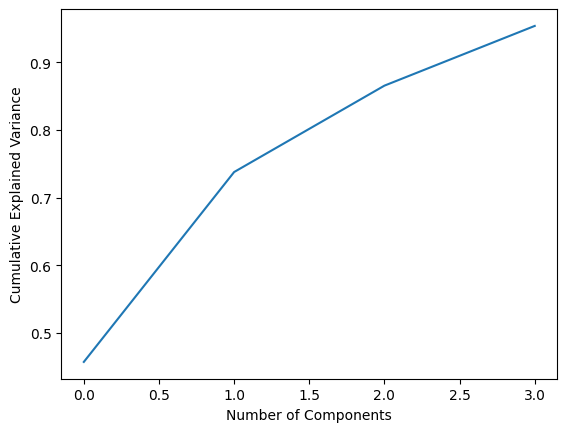

In [130]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.show()

In [131]:
from sklearn.feature_selection import SelectFromModel

# 1. Train XGBoost on all features
xgb = XGBRegressor(max_depth=3, learning_rate=0.1, n_estimators=100)
xgb.fit(X_train_scaled, y_train)

# 2. Select top features
selector = SelectFromModel(xgb, prefit=True, threshold="median")  # Keep median-importance features
X_train_selected = selector.transform(X_train_scaled)
X_test_selected = selector.transform(X_test_scaled)

print(f"Selected features: {X_train_selected.shape[1]}")

# 3. Retrain on selected features
xgb_selected = XGBRegressor(max_depth=3, learning_rate=0.1)
xgb_selected.fit(X_train_selected, y_train)
y_pred = xgb_selected.predict(X_test_selected)

print("R²:", r2_score(y_test, y_pred))

Selected features: 3
R²: -0.014401866818656517


In [19]:
thresh = 0
working_df['med_tresh'] = working_df['WS/48-1_target'].apply(lambda x:
                 0 if x < thresh else 1
                 )
working_df['med_tresh'].value_counts()/len(working_df)

med_tresh
1    0.746781
0    0.253219
Name: count, dtype: float64

In [256]:
i = 1
thresh = 0
working_df['med_tresh'] = working_df[f'WS/48-{i}_target'].apply(lambda x:
                 0 if x < thresh else 1
                 )
working_df['med_tresh'].value_counts()/len(working_df)
# 1. Generate Synthetic Data (Replace with your dataset)
X = working_df[working_df[f'WS/48-{i}_target'].notnull()][features]
y = working_df[working_df[f'WS/48-{i}_target'].notnull()]['med_tresh']

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Standardize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Apply PCA (Retain 95% variance)
pca = PCA(n_components=0.85)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print(f"Reduced features after PCA: {X_train_pca.shape[1]}")

Reduced features after PCA: 77


In [76]:
from sklearn.ensemble import RandomForestClassifier



# Train
model = RandomForestClassifier(class_weight='balanced')
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced')

In [77]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve

# Predictions
y_pred = model.predict(X_test)  # Class predictions (0/1)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probabilities for AUC

# Metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"Test Accuracy: {accuracy:.3f}")
print(f"F1 Score: {f1:.3f}")
print(f"AUC: {auc:.3f}")

# Train metrics (to check overfitting)
y_train_pred = model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"\nTrain Accuracy: {train_accuracy:.3f} (check for overfitting)")

Test Accuracy: 0.828
F1 Score: 0.906
AUC: 0.529

Train Accuracy: 1.000 (check for overfitting)


In [73]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Modèle de base
model = RandomForestClassifier(random_state=42)

# Grille d'hyperparamètres
param_dist = {
    'max_depth': [2, 3, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.8],
    'n_estimators': [10, 50, 100, 200]
}

# Recherche aléatoire (plus rapide que GridSearchCV)
random_search = RandomizedSearchCV(
    model, 
    param_distributions=param_dist,
    n_iter=20,  # Nombre de combinaisons testées
    cv=5,       # Validation croisée
    scoring='roc_auc_ovr',  # Métrique à optimiser (F1 pour les classes déséquilibrées)
    random_state=42,
    n_jobs=-1   # Utilisation de tous les CPU
)

random_search.fit(X_train, y_train)

# Meilleurs paramètres
print("Meilleurs hyperparamètres:", random_search.best_params_)

Meilleurs hyperparamètres: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 15}


c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


In [384]:
best_model = random_search.best_estimator_
print("Train F1:", f1_score(y_train, best_model.predict(X_train)))
print("Test F1:", f1_score(y_test, best_model.predict(X_test)))

Train F1: 0.9326647564469914
Test F1: 0.9553072625698324


In [385]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# 1. Récupérer le meilleur modèle
best_model = random_search.best_estimator_

# 2. Prédictions sur le train et le test
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Probabilités pour l'AUC (utilisez la classe positive, généralement [:, 1])
y_train_proba = best_model.predict_proba(X_train)[:, 1]
y_test_proba = best_model.predict_proba(X_test)[:, 1]

# 3. Calcul des métriques
metrics = {
    "Train Accuracy": accuracy_score(y_train, y_train_pred),
    "Test Accuracy": accuracy_score(y_test, y_test_pred),
    "Train F1": f1_score(y_train, y_train_pred),
    "Test F1": f1_score(y_test, y_test_pred),
    "Train AUC": roc_auc_score(y_train, y_train_proba),
    "Test AUC": roc_auc_score(y_test, y_test_proba)
}

# Affichage des résultats
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

Train Accuracy: 0.8738
Test Accuracy: 0.9144
Train F1: 0.9327
Test F1: 0.9553
Train AUC: 0.8902
Test AUC: 0.4488


In [95]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# 1. Charger les données (remplacer X, y par vos données)
# X = features, y = target (1=star, 0=non-star)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Définir les modèles et leurs grilles d'hyperparamètres pour le tuning
models = {
    "Logistic Regression": {
        "model": Pipeline([("scaler", StandardScaler()), ("lr", LogisticRegression(max_iter=1000))]),
        "params": {
            "lr__C": np.logspace(-3, 3, 7),
            "lr__class_weight": [None, "balanced"]
        }
    },
    "SVM": {
        "model": Pipeline([("scaler", StandardScaler()), ("svm", SVC(probability=True))]),
        "params": {
            "svm__C": np.logspace(-3, 3, 7),
            "svm__gamma": ["scale", "auto"] + list(np.logspace(-3, 3, 5)),
            "svm__class_weight": [None, "balanced"]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [50, 100, 200],
            "max_depth": [None, 10, 20, 30],
            "min_samples_split": [2, 5, 10],
            "class_weight": [None, "balanced"]
        }
    },
    "XGBoost": {
        "model": XGBClassifier(random_state=42),
        "params": {
            "n_estimators": [25, 50, 100, 200],
            "max_depth": [2, 3, 6, 9],
            "learning_rate": [0.001, 0.01, 0.1, 0.2],
            "scale_pos_weight": [1, np.sum(y_train == 0) / np.sum(y_train == 1)]  # Gère le déséquilibre
        }
    }
}

# 3. Entraînement, tuning et évaluation
results = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, config in models.items():
    print(f"\n=== Optimisation de {name} ===")
    
    # RandomizedSearchCV pour le fine-tuning
    search = RandomizedSearchCV(
        config["model"], 
        config["params"], 
        n_iter=10,  # Nombre d'itérations (augmentez pour plus de précision)
        cv=kf, 
        scoring="roc_auc_ovr", 
        n_jobs=-1, 
        random_state=42
    )
    search.fit(X_train, y_train)
    best_model = search.best_estimator_
    
    # Prédictions
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)
    
    # Métriques
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    train_auc = roc_auc_score(y_train, best_model.predict_proba(X_train)[:, 1])
    test_auc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1])
    
    # Stockage des résultats
    results.append({
        "Model": name,
        "Best Params": search.best_params_,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Train F1": train_f1,
        "Test F1": test_f1,
        "Train AUC": train_auc,
        "Test AUC": test_auc,
        "Overfitting (Accuracy Gap)": train_accuracy - test_accuracy
    })

# 4. Affichage des résultats
results_df = pd.DataFrame(results)
print("\n=== Résultats Finaux ===")
results_df


=== Optimisation de Logistic Regression ===

=== Optimisation de SVM ===

=== Optimisation de Random Forest ===

=== Optimisation de XGBoost ===

=== Résultats Finaux ===


,Model,Best Params,Train Accuracy,Test Accuracy,Train F1,Test F1,Train AUC,Test AUC,Overfitting (Accuracy Gap)
0,Logistic Regression,"{'lr__class_weight': None, 'lr__C': 0.001}",0.852431,0.827586,0.920337,0.905660,0.733581,0.494667,0.024844
1,SVM,"{'svm__gamma': 'scale', 'svm__class_weight': N...",0.852431,0.827586,0.920337,0.905660,0.107152,0.522000,0.024844
2,Random Forest,"{'n_estimators': 100, 'min_samples_split': 5, ...",0.994792,0.827586,0.996954,0.905660,1.000000,0.479333,0.167205
3,XGBoost,"{'scale_pos_weight': 1, 'n_estimators': 25, 'm...",0.928819,0.820690,0.959922,0.901515,0.995735,0.521000,0.108130


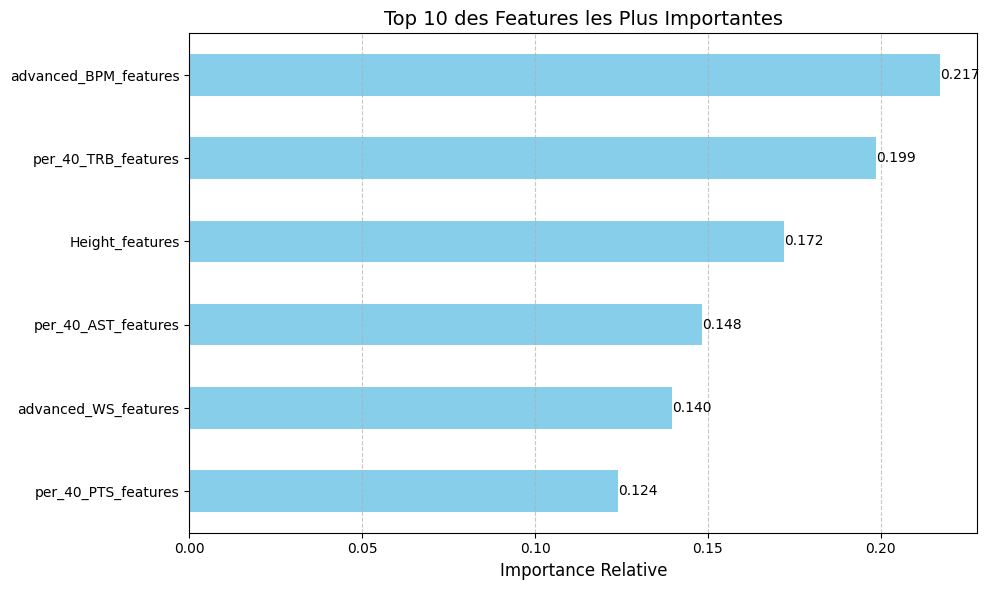

In [416]:
import matplotlib.pyplot as plt
import pandas as pd

# Récupérer l'importance des features + tri
feature_importances = pd.Series(best_model.feature_importances_, index=X.columns)
top10_features = feature_importances.sort_values(ascending=False).head(10)

# Plot avec style
plt.figure(figsize=(10, 6))
top10_features.sort_values().plot(kind='barh', color='skyblue')
plt.title('Top 10 des Features les Plus Importantes', fontsize=14)
plt.xlabel('Importance Relative', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Ajouter les valeurs sur les barres
for index, value in enumerate(top10_features.sort_values()):
    plt.text(value, index, f'{value:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [418]:
(working_df[working_df['med_tresh'] == 0]['G-1_target'].isnull().sum())

np.int64(0)

In [ ]:
active_player = []
below_zero = []
for i in range(1, 11):
    working_df['med_tresh'] = working_df[f'WS/48-{i}_target'].apply(lambda x:
                 1 if x > thresh else 0
                 )
    active_player.append(working_df[working_df[f'med_tresh'] == 1].shape[0])
    below_zero.append(working_df[(working_df[f'med_tresh'] == 0) & (working_df[f'WS/48-{i}_target'].notnull())].shape[0])
distrib_df = pd.DataFrame(
    {'season' : [i for i in range(1, 11)],
        'active' : active_player,
     'below' : below_zero}
)
distrib_df

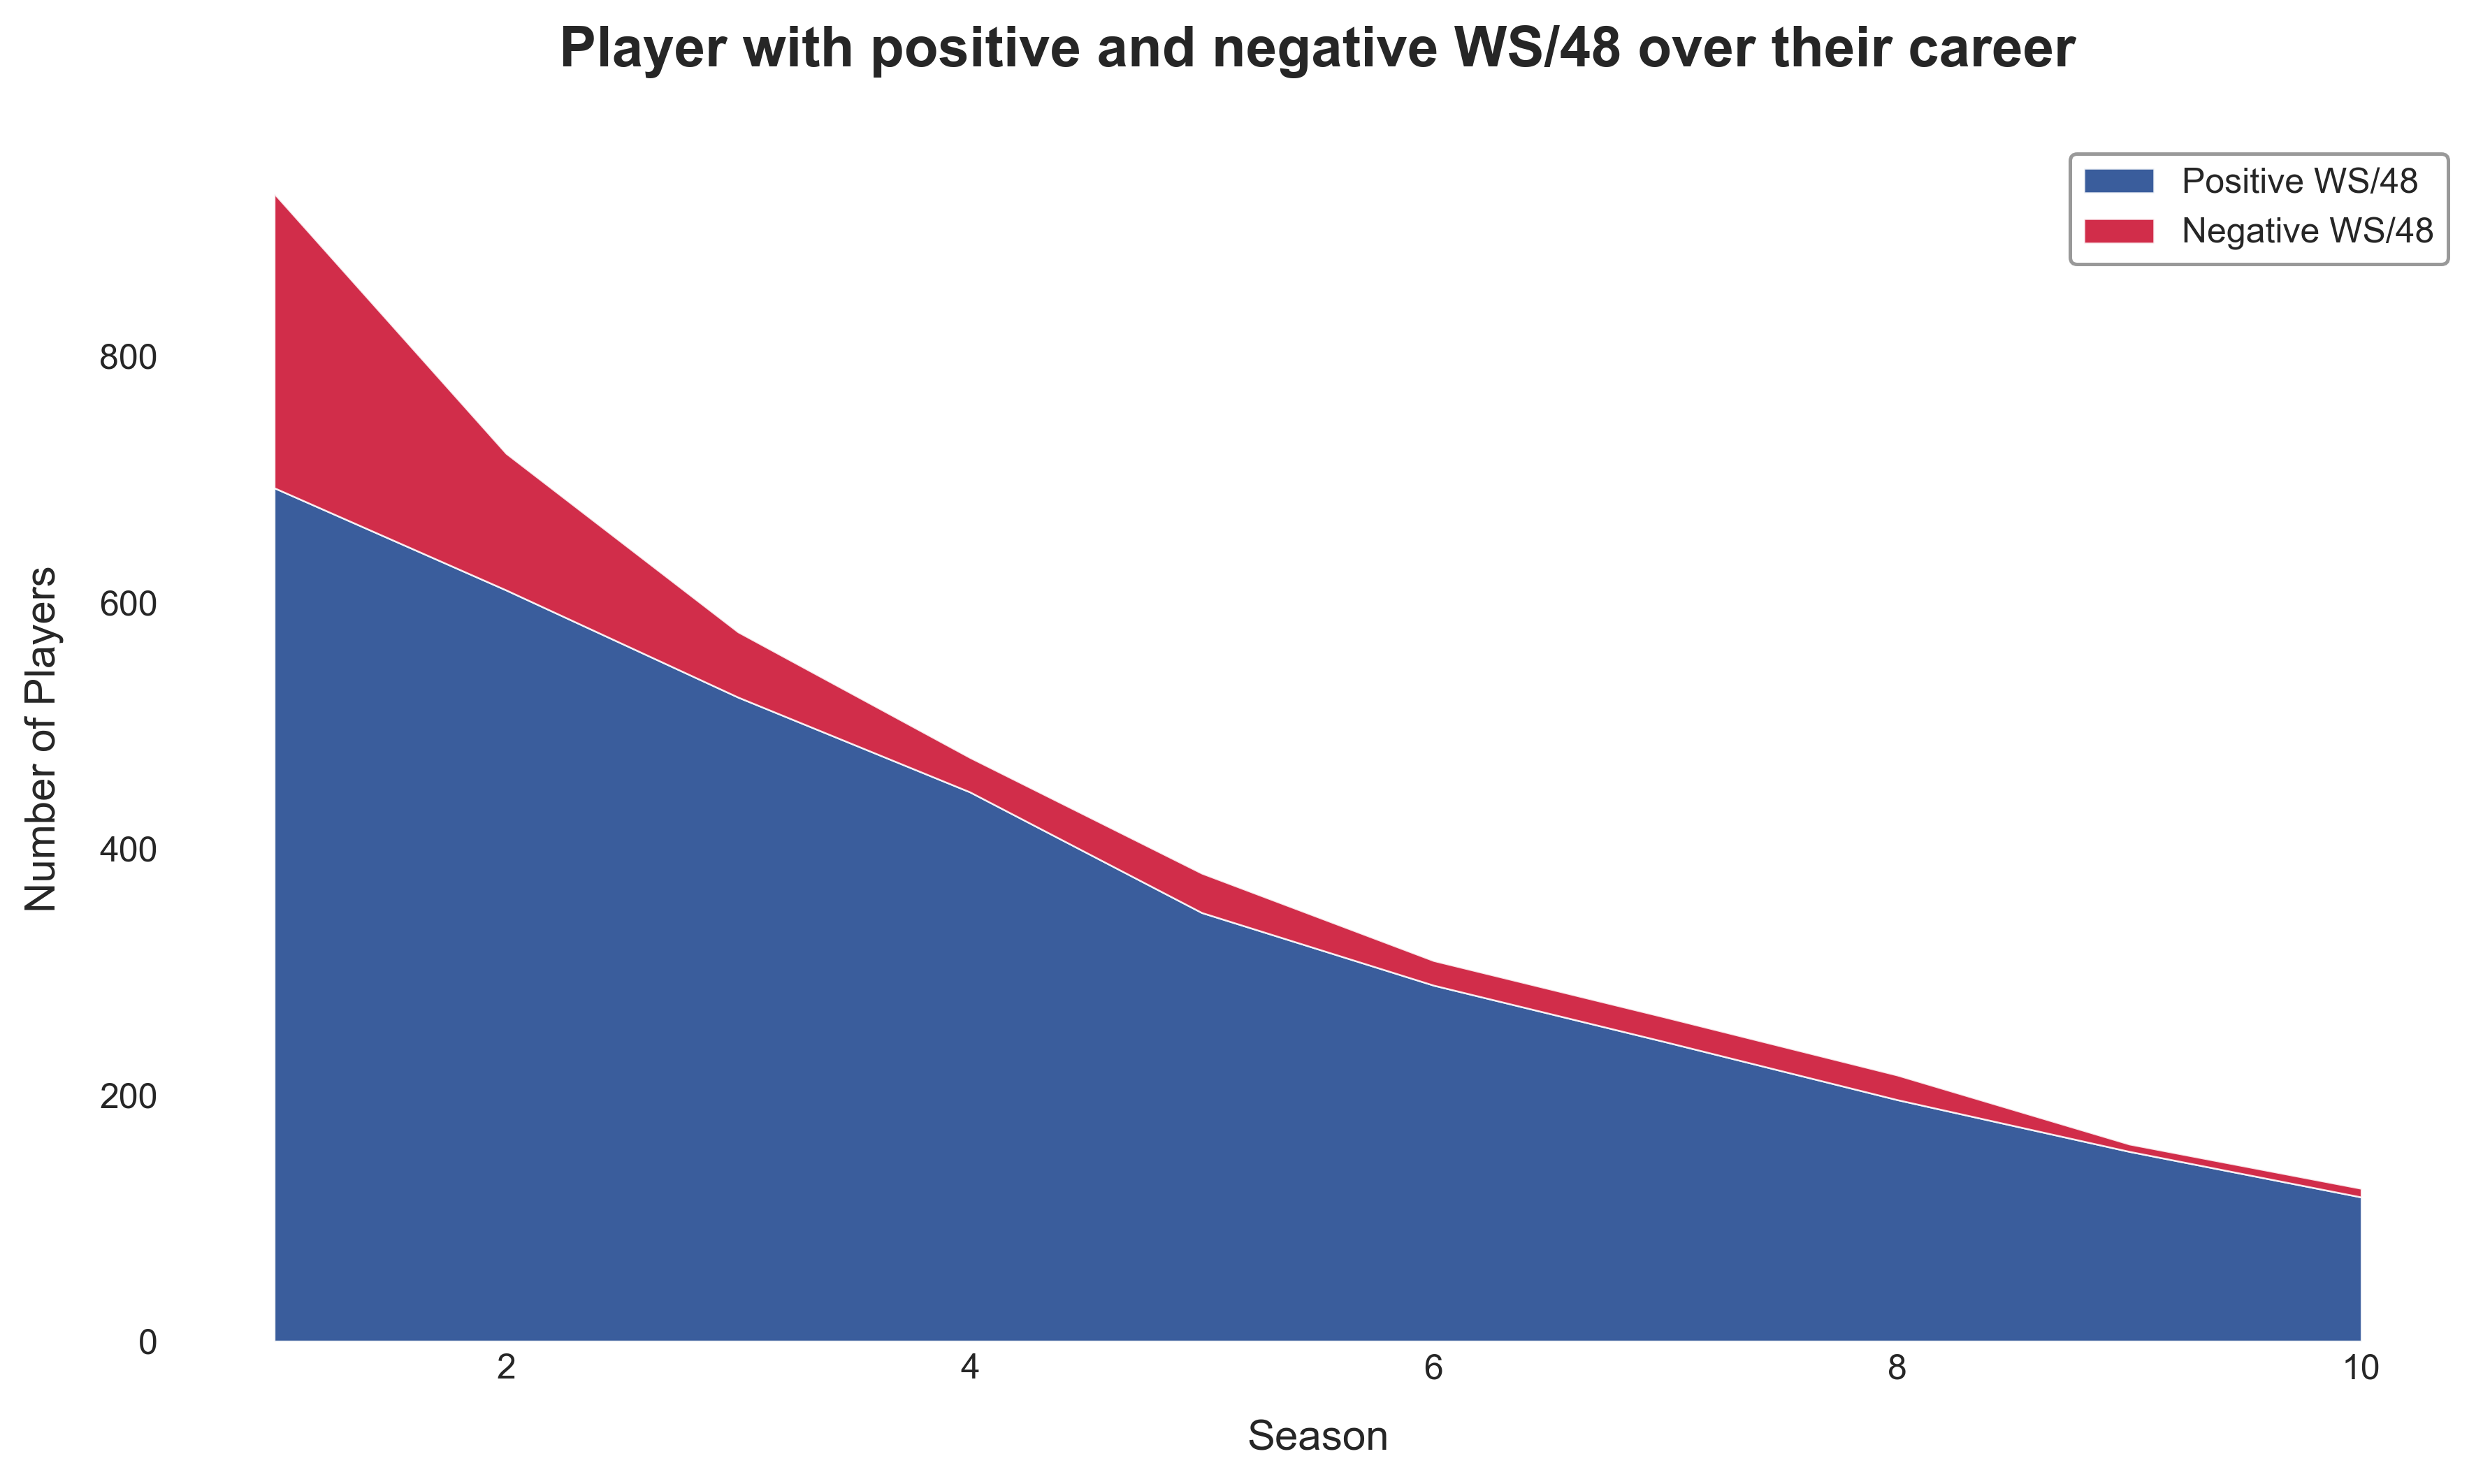

In [66]:
# Set NBA colors (red, blue, white background)
nba_red = "#C9082A"  # NBA primary red
nba_blue = "#17408B" # NBA primary blue
bg_color = "#FFFFFF" # Pure white background

# Create figure with light background
plt.figure(figsize=(10, 6), facecolor=bg_color, dpi=360)
ax = plt.gca()
ax.set_facecolor(bg_color)

# Create stack plot
plt.stackplot(
    distrib_df["season"],
    distrib_df["active"],
    distrib_df["below"],
    labels=["Positive WS/48", "Negative WS/48"],
    colors=[nba_blue, nba_red],
    alpha=0.85,
    edgecolor='white',
    linewidth=0.5
)

# --- Enhancements for Professional Look ---
# 1. Titles & Labels
plt.title(
    "Player with positive and negative WS/48 over their career",
    fontsize=16,
    pad=20,
    fontweight='bold'
)
plt.xlabel("Season", fontsize=12, labelpad=10)
plt.ylabel("Number of Players", fontsize=12, labelpad=10)

# 2. Legend (positioned neatly)
plt.legend(
    frameon=True,
    loc='upper right',
    fontsize=10,
    facecolor='white',
    edgecolor='gray'
)

# 3. Axis adjustments (remove spines, adjust ticks)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=10)

sns.despine()
# 5. Tight layout & save high-quality image
plt.tight_layout()
plt.show()

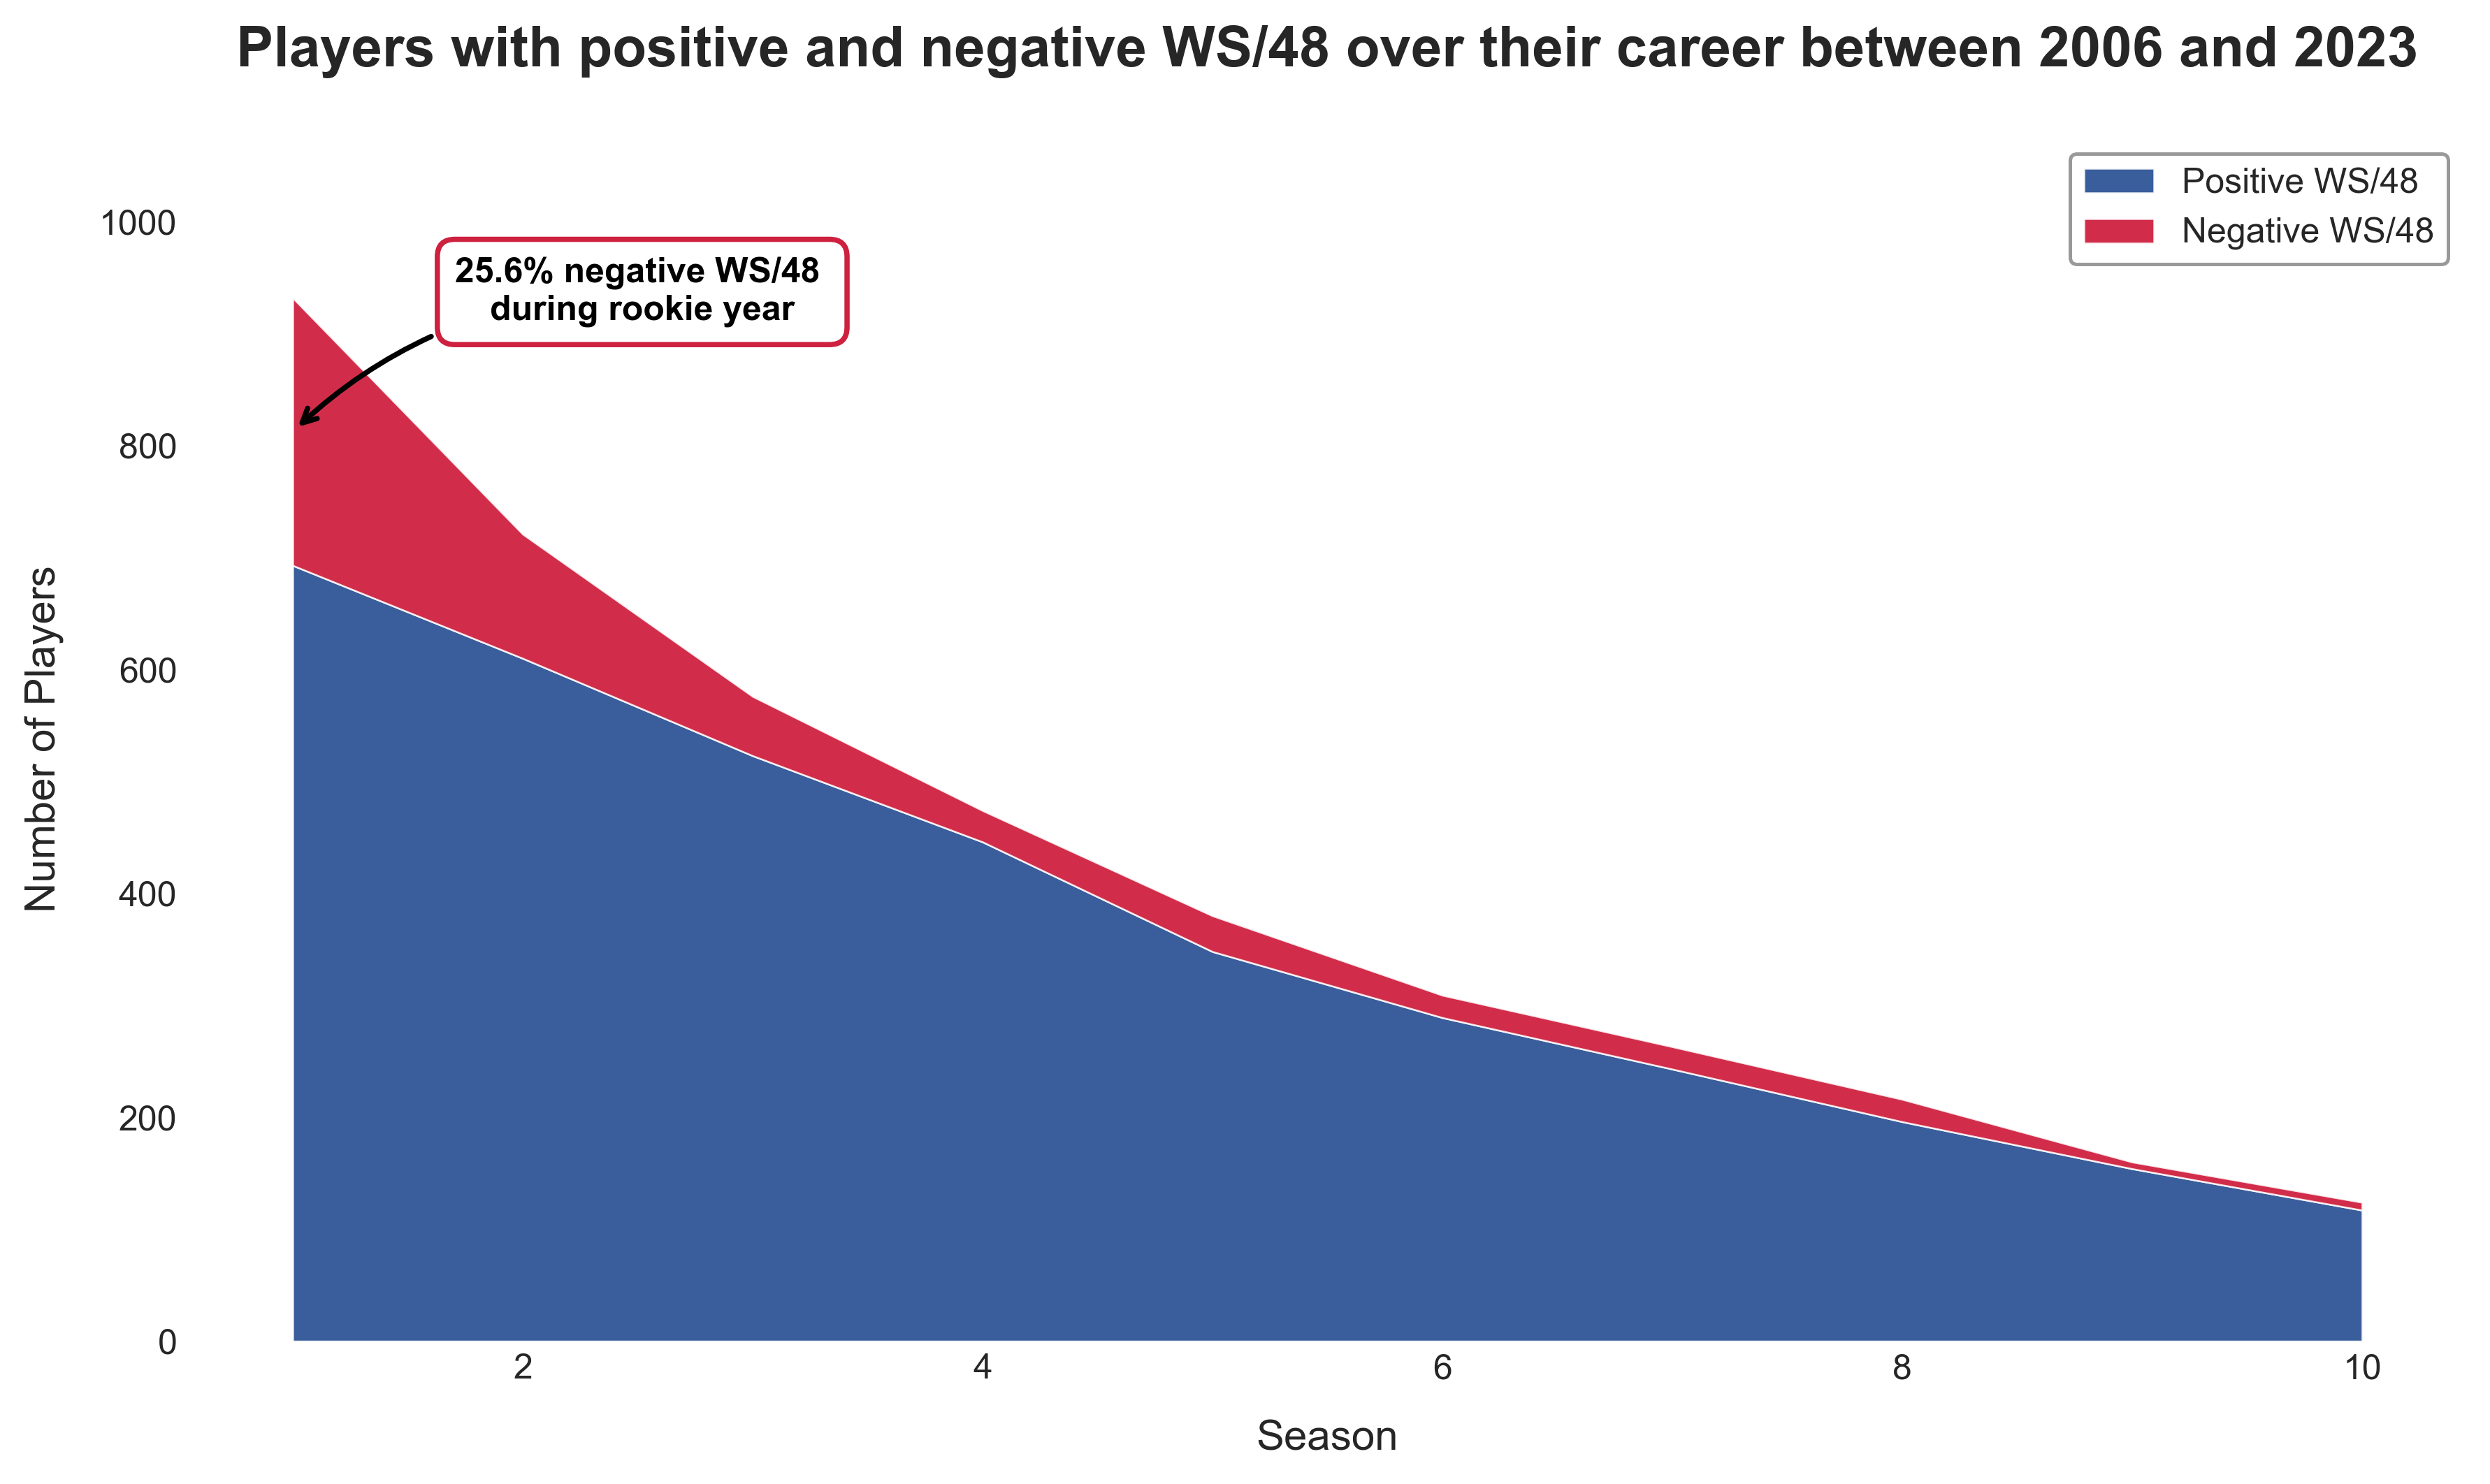

In [ ]:
# Set NBA colors (red, blue, white background)
nba_red = "#C9082A"  # NBA primary red
nba_blue = "#17408B" # NBA primary blue
bg_color = "#FFFFFF" # Pure white background

# Create figure with light background
plt.figure(figsize=(10, 6), facecolor=bg_color, dpi=360)
ax = plt.gca()
ax.set_facecolor(bg_color)

# Create stack plot
plt.stackplot(
    distrib_df["season"],
    distrib_df["active"],
    distrib_df["below"],
    labels=["Positive WS/48", "Negative WS/48"],
    colors=[nba_blue, nba_red],
    alpha=0.85,
    edgecolor='white',
    linewidth=0.5
)

# --- Calculate and add negative WS/48 proportion for season 0 ---
total_players_s0 = distrib_df['active'][0] + distrib_df['below'][0]
negative_prop_s0 = (distrib_df['below'][0] / total_players_s0) * 100

# Add annotation for season 0
plt.annotate(
    f'{negative_prop_s0:.1f}% negative WS/48 \nduring rookie year', 
    xy=(1, distrib_df['active'][0] + distrib_df['below'][0]/2),  # Point d'ancrage de la flèche (milieu de la section rouge)
    xytext=(100, 40),  # Augmentation du décalage (en points)
    textcoords='offset points',
    ha='center',
    va='center',
    fontsize=10,
    fontweight='bold',
    color='black',
    bbox=dict(
        boxstyle='round,pad=0.5',
        facecolor='white',
        alpha=0.9,
        edgecolor=nba_red,
        linewidth=1.5
    ),
    arrowprops=dict(
        arrowstyle='->',
        connectionstyle='arc3,rad=0.2',  # Courbure légère de la flèche
        color='black',
        linewidth=1.5,
        relpos=(0.5, 0.5)  # Point de connexion au centre de la boîte
    ))
# --- Enhancements for Professional Look ---
# 1. Titles & Labels
plt.title(
    "Players with positive and negative WS/48 over their career between 2006 and 2023",
    fontsize=16,
    pad=20,
    fontweight='bold'
)
plt.xlabel("Season", fontsize=12, labelpad=10)
plt.ylabel("Number of Players", fontsize=12, labelpad=10)

# 2. Legend (positioned neatly)
plt.legend(
    frameon=True,
    loc='upper right',
    fontsize=10,
    facecolor='white',
    edgecolor='gray'
)

# 3. Axis adjustments (remove spines, adjust ticks)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=10)

sns.despine()

# Adjust ylim to make space for annotation if needed
current_ymax = ax.get_ylim()[1]
ax.set_ylim(top=current_ymax*1.1 if negative_prop_s0 > 5 else current_ymax)

# Tight layout & show
plt.tight_layout()
plt.show()

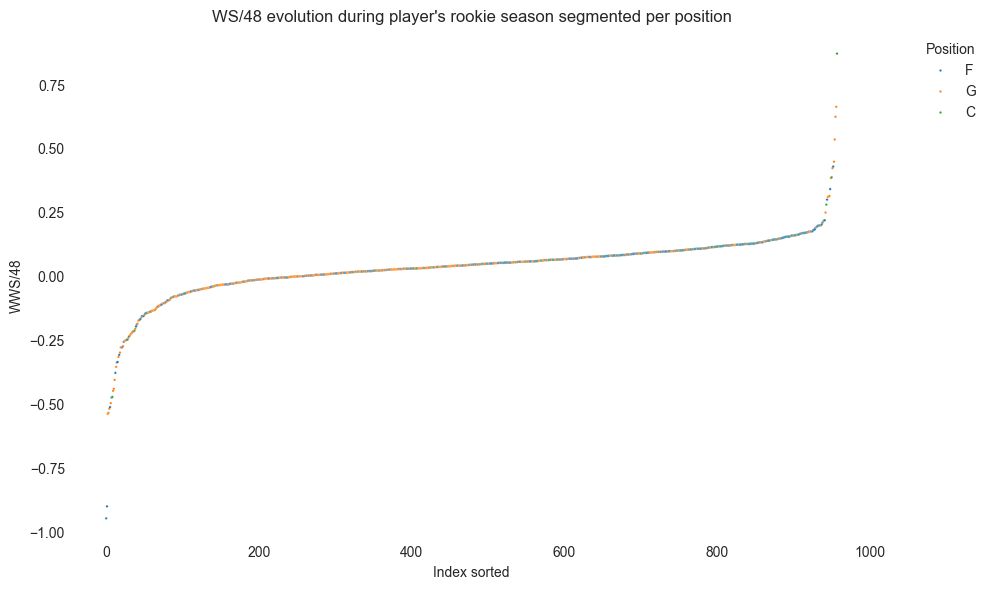

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt

# Trier les valeurs avec leur position correspondante
sorted_df = base_df[['WS/48-1_target', 'Pos_x_features']].sort_values(by='WS/48-1_target', ascending=True).reset_index(drop=True)

# Plot avec hue
sns.set_style(style='white')
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=sorted_df.index,
    y=sorted_df['WS/48-1_target'],
    hue=sorted_df['Pos_x_features'],
    palette='tab10',
    s=3,
    alpha=1
)

plt.xlabel('Index sorted')
plt.ylabel('WWS/48')
plt.title("WS/48 evolution during player's rookie season segmented per position")
plt.legend(title='Position', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [166]:
base_df.groupby('Pos_x_features')['WS/48-1_target'].std()

Pos_x_features
C    0.152114
F    0.122141
G    0.119454
Name: WS/48-1_target, dtype: float64

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_15032\2701060911.py:8: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  g = sns.catplot(


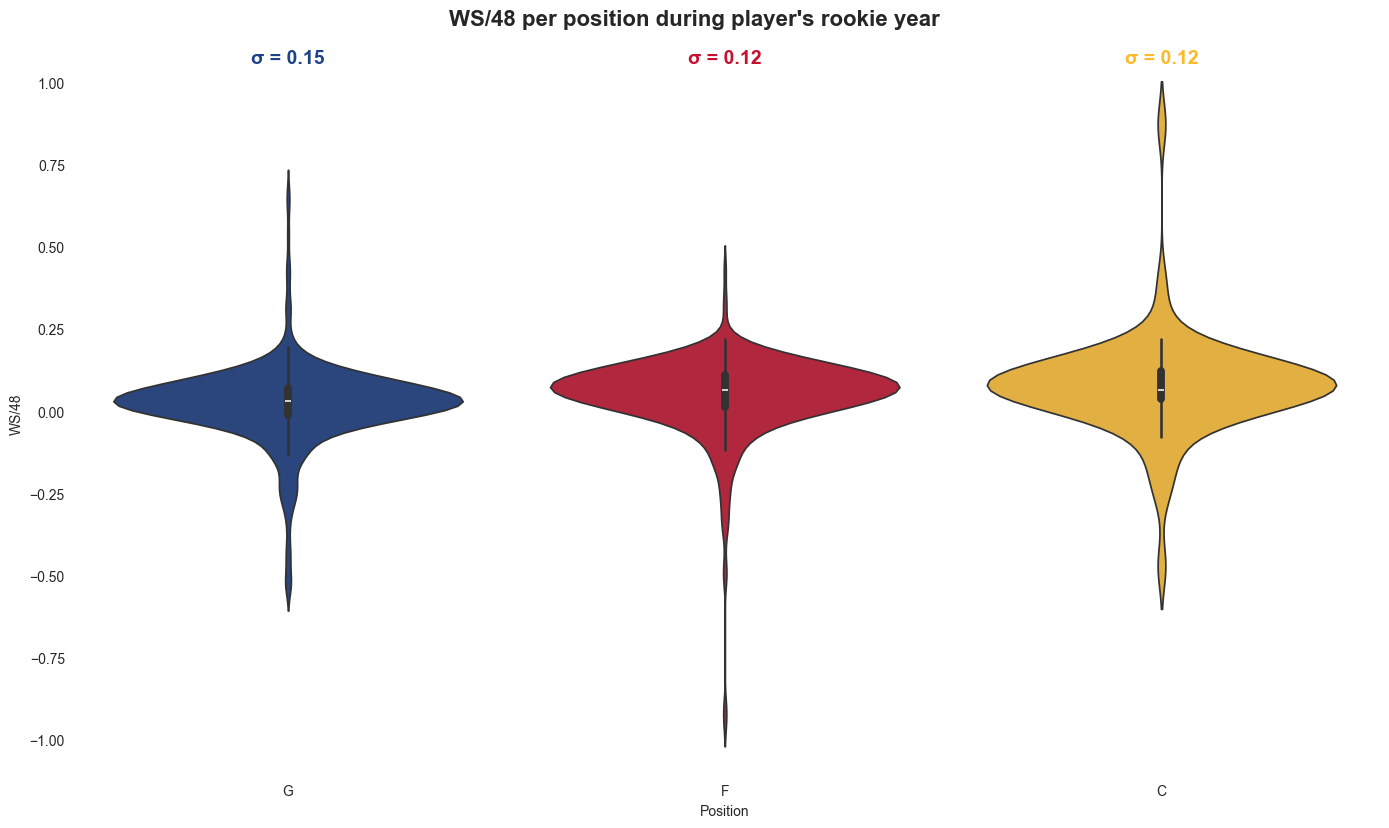

In [169]:
std_values = base_df.groupby('Pos_x_features')['WS/48-1_target'].std()

nba_palette = ['#1D428A',  # Warriors Blue
               '#C8102E',  # Bulls Red
               '#FDB927',  # Lakers Gold
               '#000000',  # Nets Black
               '#007A33']  # Celtics Green
g = sns.catplot(
    data=base_df,
    x='Pos_x_features',
    y='WS/48-1_target',
    kind='violin',
    palette=nba_palette,
    hue='Pos_x_features',
    height=8,
    aspect=1.75,
)

# Ajout des écarts-types sur le graphique
for i, pos in enumerate(std_values.index):
    # Position x du groupe
    x_pos = i  
    # Valeur de l'écart-type
    std = std_values.loc[pos]
    # Annotation au-dessus des violons
    g.ax.text(
        x_pos,
        base_df['WS/48-1_target'].max() * 1.2,  # Position y légèrement au-dessus du max
        f"σ = {std:.2f}",                         # Formatage à 2 décimales
        ha='center',                              # Alignement horizontal
        va='bottom',                              # Alignement vertical
        fontsize=14,
        color=nba_palette[i],                     # Couleur correspondante
        fontweight='bold'
    )


g.set_axis_labels("Position", "WS/48")
g.fig.suptitle("WS/48 per position during player's rookie year", y=1.03, fontsize=16,
    fontweight='bold')
plt.show()


In [212]:
i = 1
j = 2
working_df[working_df[f'MP-{i}_target'] > j]['med_tresh'].value_counts()/len(working_df[working_df[f'MP-{i}_target'] > j])

med_tresh
1    0.880565
0    0.119435
Name: count, dtype: float64

In [261]:
working_df[working_df['MP-1_target'] < 12]['med_tresh'].value_counts()

med_tresh
0    33
1    25
Name: count, dtype: int64

(0.0, 100.0)

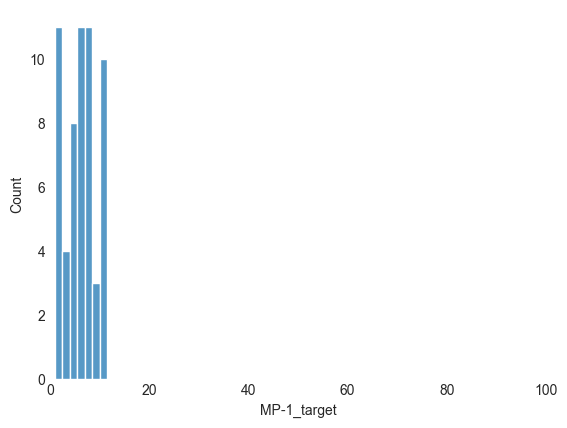

In [251]:
sns.histplot(working_df[working_df['MP-1_target'] < 12]['MP-1_target'])
plt.xlim([0, 100])

In [240]:
for i in working_df.columns:
    print(i)

Unnamed: 0
player_id
G-1_target
G-2_target
G-3_target
G-4_target
G-5_target
G-6_target
G-7_target
G-8_target
G-9_target
G-10_target
G-11_target
G-12_target
G-13_target
G-14_target
G-15_target
G-16_target
G-17_target
G-18_target
G-19_target
G-20_target
G-21_target
G-22_target
MP-1_target
MP-2_target
MP-3_target
MP-4_target
MP-5_target
MP-6_target
MP-7_target
MP-8_target
MP-9_target
MP-10_target
MP-11_target
MP-12_target
MP-13_target
MP-14_target
MP-15_target
MP-16_target
MP-17_target
MP-18_target
MP-19_target
MP-20_target
MP-21_target
MP-22_target
WS-1_target
WS-2_target
WS-3_target
WS-4_target
WS-5_target
WS-6_target
WS-7_target
WS-8_target
WS-9_target
WS-10_target
WS-11_target
WS-12_target
WS-13_target
WS-14_target
WS-15_target
WS-16_target
WS-17_target
WS-18_target
WS-19_target
WS-20_target
WS-21_target
WS-22_target
WS/48-1_target
WS/48-2_target
WS/48-3_target
WS/48-4_target
WS/48-5_target
WS/48-6_target
WS/48-7_target
WS/48-8_target
WS/48-9_target
WS/48-10_target
WS/48-11_target
WS/

In [248]:
working_df['per_40_MP_features']

0      1289.0
1      1187.0
2      1016.0
3      1004.0
4       910.0
        ...  
953     981.0
954    1051.0
955     558.0
956     990.0
957    1102.0
Name: per_40_MP_features, Length: 932, dtype: float64

In [250]:
working_df[working_df['med_tresh'] == 0]['per_40_MP_features']

3      1004.0
15      870.0
17      935.0
36     1194.0
37     1027.0
        ...  
913    1154.0
916    1288.0
924    1303.0
927    1123.0
954    1051.0
Name: per_40_MP_features, Length: 110, dtype: float64

(0.0, 82.0)

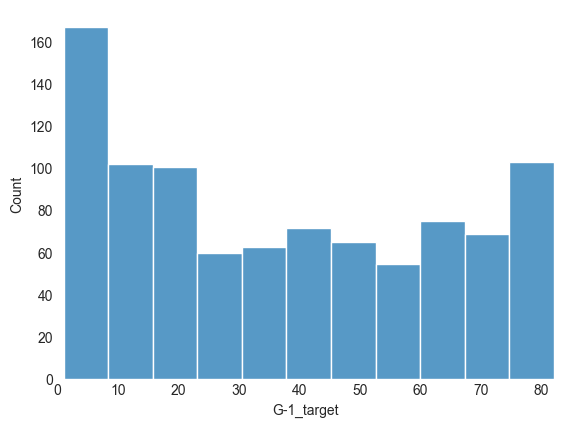

In [231]:
sns.histplot(working_df['G-1_target'])
plt.xlim([0, 82])